In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter

We want to find the $k$-dependent eigenvalues of matrix (4.12) in the Overleaf. If, for a given temperature $\beta$, all eigenvalues for all $k$ are negative, the uniform distribution is stable (no clustering).
The matrix depends on pairwise interaction potential $W$ (rather its Fourier transform). We consider the Gaussian case.

For the wrapped Gaussian defined on $[-L/2,L/2]$ we have that $$W(r) = -\sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr$$
$$ = -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$= -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr$$
$$= -\int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr$$
$$= -\sqrt{2\pi \sigma^2}e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -\sqrt{2\pi \sigma^2} e^{-\sigma^{2}k^{2}/2}.$$

Alternative: Try non-wrapped Gaussian:
$$
\hat{W}(k)=-\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right)
$$

In [3]:
#Wrapped Gaussian model
σ = np.sqrt(0.5)  # variance
L = 10 # boxlength

def W_hat(k):
    W_hat_k = -np.sqrt(2*np.pi)*σ*np.exp(-σ**2 * k**2 /2) #
    return W_hat_k

# non-wrapped case:
#from scipy.special import erf
#def W_hat(k):
#    W_hat_k = -np.sqrt(2*np.pi)*σ * np.exp(-σ**2*k**2/2)*np.real( erf( (0.5*L + 1j*k*σ**2)/(np.sqrt(2*σ**2)) ) )
#    return W_hat_k

# The matrix A. We restrict it to the first "dim" rows.
def matrix(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat(k)/L 
    return A_k

In [4]:
# For a number of temperatures and friction values, obtain largest eigenvalues.
def function_params(β,γ):
    
    k_max = 30  # number of wavenumbers to test.
    
    approximation_dimension = 30  # number of matrix rows to consider.
    maximum = np.max(np.real(np.linalg.eigvals(matrix(0.,β,γ,L,approximation_dimension))))
    
    # find maximum eigenvalue for all wavenumbers
    for k in range(k_max - 1):
        #change to maximum real part
        partial_max = np.max(np.real(np.linalg.eigvals(matrix(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
        #print(partial_max,maximum)
        if partial_max > maximum:
            maximum = partial_max
        partial_max = np.max(np.real(np.linalg.eigvals(matrix(-2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
        #print(partial_max,maximum)
        if partial_max > maximum:
            maximum = partial_max
    spectral_radius = maximum
    
    return spectral_radius
    
def function():
    N_β = 1    # Number of temperature points.
    N_γ = 300      # Number of friction points.
    β_list = np.array([25])
    γ_list = np.linspace(0.01,3.0,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    
    spectral_radius = np.zeros((N_β,N_γ))  # store largest real part of eigenvalues here.
    
    # for all beta and gamma...
    for i in range(len(β_list)):
        print("beta: ", i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = function_params(β,γ)
            spectral_radius[i,j] = maximum
    
    return β_list,γ_list,spectral_radius



# $(2\pi)^{1/2} * \sigma \frac{N}{L} \kappa$ in 1D
# $(2\pi) * \sigma^2 \frac{N}{L^2} \kappa$ in 2D

In [6]:
# Print critical beta given by literature.
print('Theoretical critical in 1D beta = ',L/(σ*np.sqrt(2*np.pi)))
print('Theoretical critical in 2D beta = ',L**2/(σ**2*2*np.pi))    

Theoretical critical in 1D beta =  5.6418958354775635
Theoretical critical in 2D beta =  31.83098861837906


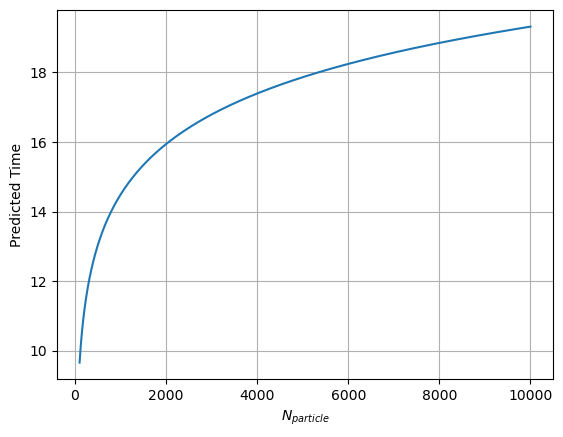

In [7]:
γ = 0.1
β = 25
γ_max = function_params(β,γ)
γ_max_0_1 = function_params(β,0.1)
γ_max_3_0 = function_params(β,3.0)
N_list = np.linspace(100,10000,10000)
plt.plot(N_list,np.log(N_list)/(2*γ_max))
plt.grid()
plt.xlabel('$N_{particle}$')
plt.ylabel('Predicted Time')
plt.show()

1.8696119468337336


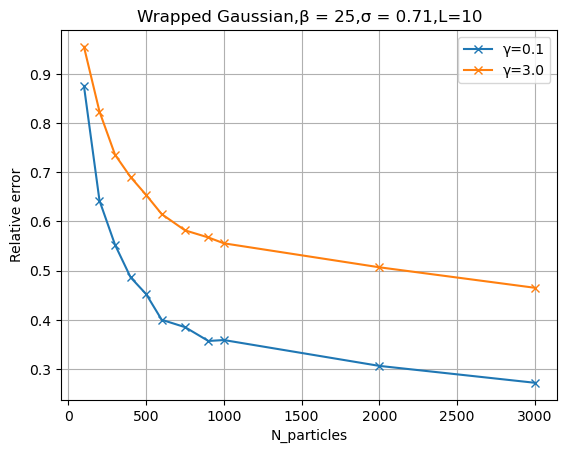

In [8]:
times01 = np.array([1.2025,3.9745, 5.3534999999999995,6.4545,7.139000000000001, 8.049, 8.5375, 9.174000000000001, 9.289, 11.059000000000001, 12.2255])
times3 = np.array([2.51625, 11.418000000000001, 18.4041, 22.6479, 26.2515,30.06135,33.78045,35.9073,37.4715, 45.752849999999995, 52.26540000000001])
N_parts = np.array([100, 200, 300, 400, 500, 600, 750, 900, 1000, 2000, 3000])
theory01 = np.log(N_parts)/(2*γ_max_0_1)
theory3 = np.log(N_parts)/(2*γ_max_3_0)
plt.plot(N_parts,np.abs(theory01-times01)/theory01,'x-',label='γ=0.1')
plt.plot(N_parts,np.abs(theory3-times3)/theory3,'x-',label='γ=3.0')
plt.ylabel('Relative error')
plt.grid()
plt.xlabel('N_particles')
plt.title('Wrapped Gaussian,β = 25,σ = 0.71,L=10')
plt.legend()
print((theory3/times3)[-1])

In [16]:
# For all temperatures and frictions, obtain largest eigenvalues.
β_list,γ_list,spectral_radius = function()
np.savetxt("Gaussian_theory.csv", 1/(2*spectral_radius), delimiter=",")
np.savetxt("x_theory.csv", γ_list, delimiter=",")

beta:  0


In [10]:
# Print the first beta at which eigenvalues become positive (should align with theoretical prediction above):

gamma_idx = 2 # which gamma to consider (T_crit should be independent of it anyway)
beta_c = β_list[ np.argmax(spectral_radius[:,gamma_idx]>0) ]
print("Crit. Beta: ", beta_c )

print("In 2D, this should then be ", beta_c**2)

Crit. Beta:  25
In 2D, this should then be  625


In [11]:
N100_3000 = [2.9337141686438746, 3.03846538627501, 3.074666061931924, 3.1112992597950884, 3.148596136380848, 3.392370756000258, 4.07351023699521, 4.936084011759588, 5.735860514509724, 7.817914821773245, 10.127958813750958, 12.474469364717748, 14.840529353403415]
N600_3000 =[2.505264178684337, 2.616407174156163, 2.601135513932554, 2.5595281115597417,2.5724877321893125,2.7901765039189783,3.505542932860121, 4.36064445421437, 5.0936882541344835, 6.797838644286132, 9.018339277351899, 11.274186952770158, 13.49173679767955]
gammas = [0.01, 0.025,0.05,0.075,0.1,0.25,0.5,0.75,1,1.5,2,2.5,3]

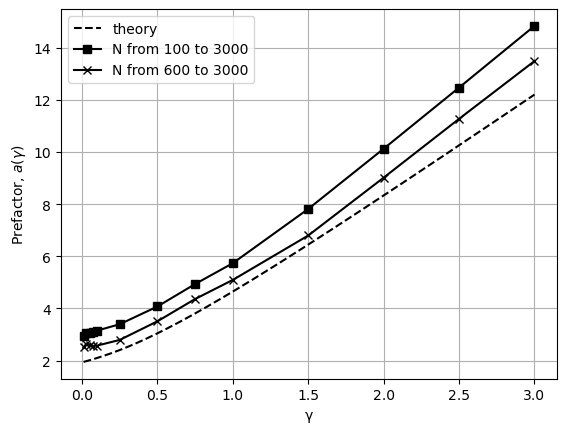

In [12]:
# plot the eigenvalue against beta
#arr = np.loadtxt('a_fit.csv', delimiter=",")
plt.plot(γ_list,1/(2*spectral_radius[0,:]),'--k',label='theory')
plt.plot(gammas,N100_3000,'s-k',label='N from 100 to 3000')
plt.plot(gammas,N600_3000,'x-k',label='N from 600 to 3000')
plt.grid()
plt.legend()
#plt.xscale('log')
#plt.yscale('log')
#plt.title('γ='+str(γ_list[gamma_idx]))
plt.xlabel('γ')
plt.ylabel('Prefactor, $a(γ)$')
plt.savefig('theoryvssim.pdf')
plt.show()

In [13]:
# plot time to onset of clustering (correct formula?)

plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-150,:]),label = 'β='+str(β_list[-150]))
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]),label = 'β='+str(β_list[-1]))
plt.xlabel('γ')
plt.legend()
plt.ylabel('Theoretical Cluster Time for 1000 particles')
plt.show()

IndexError: index -150 is out of bounds for axis 0 with size 1

In [ ]:
spectral_radius[spectral_radius > 0]

In [ ]:
fs = 11

# Create meshgrid
X, Y = np.meshgrid(γ_list, β_list)

# Clear any previous figures
plt.close('all')

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 15))
ax = fig.add_subplot(111, projection='3d')

# Normalize the spectral radius for coloring
norm = Normalize(vmin=spectral_radius.min(), vmax=spectral_radius.max())  # Normalize the spectral radius
colormap = cm.autumn_r  # Red-Blue colormap, reversed to have black at the lowest value

# Plot the surface with the colormap
surf = ax.plot_surface(X, Y, spectral_radius, cmap=colormap, edgecolor='none', facecolors=colormap(norm(spectral_radius)), alpha=0.9)

# Find the index in β_list closest to beta_c
beta_c_idx = np.abs(β_list - beta_c).argmin()

# Extract the spectral radius values along β = beta_c
line_gamma = γ_list  # γ_list is along the x-axis
line_spectral_radius = spectral_radius[beta_c_idx, :]  # Values at β = beta_c
# Plot the red dashed line on top of the surface (ensure it's on top)

# Highlight grid lines at beta_c by plotting a dashed, bold black line
ax.plot(line_gamma, [beta_c] * len(line_gamma), line_spectral_radius, color='black', linestyle='--', linewidth=2, zorder=10, label=r'$\beta_c$')

# Set axis labels
ax.set_xlabel(r'$\gamma$', labelpad=20,fontsize=2*fs)
ax.set_ylabel(r'$\beta$', labelpad=20,fontsize=2*fs)
ax.zaxis.set_rotate_label(False) 
ax.set_zlabel('$\psi_{\max}$', rotation = 0, labelpad=18,fontsize=2*fs)

# Set title with inserted variables σ and L
#fig.suptitle(f'Gaussian potential for $\\sigma = {σ}$ and $L = {L}$', fontsize=16, va='bottom', ha='center', y=0.68)

# Set ticks for each axis
ax.set_xticks(np.arange(round(γ_list.min(), 1), round(γ_list.max(), 1) + 0.5, 0.5))  # γ-axis ticks
ax.set_yticks(np.arange(round(β_list.min(), 1), round(β_list.max(), 1) + 0.5, 0.5))  # β-axis ticks
#ax.set_zticks(np.arange(round(spectral_radius.min(), 3), round(spectral_radius.max(), 3) + 0.002, 0.002))  # z-axis ticks

# Format ticks
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1 decimal place for x-axis
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1 decimal place for y-axis
#ax.zaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # 3 decimal places for z-axis

# We change the fontsize of minor ticks label 
ax.tick_params(axis='both', which='major', labelsize=fs)
ax.tick_params(axis='both', which='minor', labelsize=fs)

# Rotate the view to look from the beta axis
ax.view_init(elev=10, azim=-30)  # Adjust elevation and azimuth for desired perspective

# Add legend and position it top-right below the title
ax.legend(loc='upper right', fontsize=2*fs, bbox_to_anchor=(1, 0.8))  # Adjust position to be below the title

# Show plot
plt.savefig('spec_Gaussian.eps')
plt.show()


In [ ]:
index = np.argmax(spectral_radius[:,gamma_idx]>0)+1
β_list_filter = β_list[index:]
γ_list_filter = γ_list
spectral_radius_filter = 1/spectral_radius[index:,:]
print(spectral_radius_filter.size)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Assuming γ_list_filter, β_list_filter, and spectral_radius_filter are already defined

# Create meshgrid
X, Y = np.meshgrid(γ_list_filter, β_list_filter)

# Downsample the data to increase the spacing between the wires
factor = 1  # Increase this factor to further coarsen the mesh
X_downsampled = X[::factor, ::factor]
Y_downsampled = Y[::factor, ::factor]
spectral_radius_filter_downsampled = spectral_radius_filter[::factor, ::factor]

# Clear any previous figures
plt.close('all')

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 15))
ax = fig.add_subplot(111, projection='3d')

# Plot the wireframe with downsampled data
wireframe = ax.plot_wireframe(X_downsampled, Y_downsampled, spectral_radius_filter_downsampled, color='k', linewidth=0.1)

# Set title with inserted variables σ and L
#fig.suptitle(f'Gaussian potential for $\\sigma = {σ}$ and $L = {L}$', fontsize=16, va='bottom', ha='center', y=0.68)
# Set axis labels
ax.set_xlabel(r'$\gamma$', labelpad=20, fontsize = 2*fs)
ax.set_ylabel(r'$\beta$', labelpad=20, fontsize = 2*fs)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel('$\psi_{\max}^{-1}$', rotation = 0, labelpad=15, fontsize = 2*fs)

# Adjust the ticks on the gamma (x-axis)
gamma_ticks = np.arange(min(γ_list_filter), max(γ_list_filter) + 0.5, 0.5)  # Set ticks at intervals of 0.5
ax.set_xticks(gamma_ticks)  # Apply the ticks to the axis
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Set 1 decimal place for x-axis

# Format ticks for other axes
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1 decimal place for y-axis
ax.zaxis.set_major_formatter(FormatStrFormatter('%.0f'))  # 0 decimal places for z-axis

# We change the fontsize of minor ticks label 
ax.tick_params(axis='both', which='major', labelsize=fs)
ax.tick_params(axis='both', which='minor', labelsize=fs)

# Rotate the view to look from the beta axis
ax.view_init(elev=10, azim=30)  # Adjust elevation and azimuth for desired perspective

# Show plot
plt.savefig('linear_in_friction_Gaussian.eps')
plt.show()

